In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from eheatmap import eheatmap

In [2]:
# ============================================================
# 1. Generate data with 3 distinct clusters
# ============================================================
np.random.seed(42)

n_rows, n_cols = 30, 20
cluster1_rows, cluster2_rows, cluster3_rows = 10, 10, 10
group1_cols, group2_cols, group3_cols = 7, 7, 6

data = np.zeros((n_rows, n_cols))

# Cluster 1: High expression in the first group of samples
for i in range(cluster1_rows):
    data[i, :group1_cols] = np.random.normal(2.0, 0.3, group1_cols)
    data[i, group1_cols:] = np.random.normal(-1.0, 0.3, n_cols - group1_cols)

# Cluster 2: High expression in the second group of samples
for i in range(cluster1_rows, cluster1_rows + cluster2_rows):
    data[i, :group1_cols] = np.random.normal(-1.0, 0.3, group1_cols)
    data[i, group1_cols:group1_cols+group2_cols] = np.random.normal(2.0, 0.3, group2_cols)
    data[i, group1_cols+group2_cols:] = np.random.normal(-1.0, 0.3, group3_cols)

# Cluster 3: High expression in the third group of samples
for i in range(cluster1_rows + cluster2_rows, n_rows):
    data[i, :group1_cols+group2_cols] = np.random.normal(-1.0, 0.3, group1_cols+group2_cols)
    data[i, group1_cols+group2_cols:] = np.random.normal(2.0, 0.3, group3_cols)


In [3]:
data

array([[ 2.14901425,  1.95852071,  2.19430656,  2.45690896,  1.92975399,
         1.92975891,  2.47376384, -0.76976958, -1.14084232, -0.83723199,
        -1.13902531, -1.13971893, -0.92741132, -1.57398407, -1.51747535,
        -1.16868626, -1.30384934, -0.9057258 , -1.27240722, -1.42369111],
       [ 2.43969463,  1.93226711,  2.02025846,  1.57257554,  1.83668518,
         2.03327678,  1.65470193, -0.88729059, -1.18019161, -1.08750812,
        -1.18051198, -0.44431654, -1.00404917, -1.31731328, -0.75323653,
        -1.36625309, -0.93734092, -1.58790104, -1.39845581, -0.94094163],
       [ 2.22153997,  2.05141048,  1.96530552,  1.90966889,  1.5564434 ,
         1.78404674,  1.86180837, -0.68286333, -0.89691451, -1.52891205,
        -0.90277481, -1.11552468, -1.2030766 , -0.81649711, -0.69070014,
        -0.72061596, -1.25176526, -1.09276371, -0.90062097, -0.70733646],
       [ 1.85624773,  1.94430231,  1.66809951,  1.64113801,  2.24375775,
         2.40687201,  1.97839696, -0.69894013, -

In [4]:
df = pd.DataFrame(
    data,
    index=[f"Gene_{i+1}" for i in range(n_rows)],
    columns=[f"Sample_{i+1}" for i in range(n_cols)]
)

In [5]:
df

,Sample_1,Sample_2,Sample_3,Sample_4,Sample_5,Sample_6,Sample_7,Sample_8,Sample_9,Sample_10,Sample_11,Sample_12,Sample_13,Sample_14,Sample_15,Sample_16,Sample_17,Sample_18,Sample_19,Sample_20
Gene_1,2.149014,1.958521,2.194307,2.456909,1.929754,1.929759,2.473764,-0.769770,-1.140842,-0.837232,-1.139025,-1.139719,-0.927411,-1.573984,-1.517475,-1.168686,-1.303849,-0.905726,-1.272407,-1.423691
Gene_2,2.439695,1.932267,2.020258,1.572576,1.836685,2.033277,1.654702,-0.887291,-1.180192,-1.087508,-1.180512,-0.444317,-1.004049,-1.317313,-0.753237,-1.366253,-0.937341,-1.587901,-1.398456,-0.940942
Gene_3,2.221540,2.051410,1.965306,1.909669,1.556443,1.784047,1.861808,-0.682863,-0.896915,-1.528912,-0.902775,-1.115525,-1.203077,-0.816497,-0.690700,-0.720616,-1.251765,-1.092764,-0.900621,-0.707336
Gene_4,1.856248,1.944302,1.668100,1.641138,2.243758,2.406872,1.978397,-0.698940,-0.891509,-1.193536,-0.891581,-0.538589,-1.010748,-0.530607,-1.785924,-0.753429,-0.973886,-1.089702,-0.972472,-1.596271
Gene_5,1.934098,2.107134,2.443368,1.844519,1.757452,1.849473,2.274621,-0.901375,-1.158928,-0.846020,-0.970877,-0.709407,-1.210616,-1.098299,-1.117632,-1.439054,-0.911164,-0.921683,-0.998466,-1.070376
Gene_6,1.575389,1.873806,1.897186,1.759317,1.951614,2.121215,2.565856,-0.947627,-0.922735,-1.022334,-1.575631,-1.007954,-0.981931,-0.261027,-1.057708,-0.909536,-1.010414,-1.350603,-0.657153,-0.774420
Gene_7,2.237310,1.727184,2.420838,1.579445,2.176057,2.657137,1.702839,-1.169889,-0.970105,-1.151043,-1.465199,-0.979431,-1.318691,-0.857922,-1.275827,-0.535020,-1.234976,-1.096618,-0.755945,-1.369259
Gene_8,2.068238,2.392143,1.517755,2.055390,2.077965,2.234547,1.628915,-1.396137,-0.843418,-0.910905,-0.924852,-0.896066,-1.204007,-0.930324,-0.912078,-1.214305,-0.440268,-0.857850,-1.357391,-0.803034
Gene_9,1.707595,2.236125,2.347579,1.753795,2.289013,2.123834,2.246618,-0.430962,-1.073616,-1.226121,-1.266854,-1.244743,-1.023131,-0.897654,-0.916993,-0.751845,-0.996099,-0.563940,-1.079397,-0.183949
Gene_10,2.187700,1.742853,1.678732,2.144742,1.932961,2.214200,2.141971,-1.021849,-1.254038,-1.454454,-1.133954,-0.743080,-0.935772,-1.373722,-0.948046,-0.884405,-1.265157,-0.953882,-0.982537,-1.342891


In [6]:
# ============================================================
# 2. Generate row and column annotations
# ============================================================
row_anno = pd.DataFrame({
    "Group": [f"Group_{np.random.choice(['A', 'B', 'C'])}" for _ in range(n_rows)],
    "Score": np.random.uniform(0, 100, n_rows),
    "Type": [np.random.choice(["Type1", "Type2", "Type3"]) for _ in range(n_rows)]
}, index=df.index)

col_anno = pd.DataFrame({
    "Treatment": [np.random.choice(["Control", "Drug_A", "Drug_B"]) for _ in range(n_cols)],
    "Time": [f"T{i}" for i in np.random.randint(1, 5, n_cols)],
    "Value": np.random.uniform(0, 1, n_cols)
}, index=df.columns)


In [7]:
row_anno

,Group,Score,Type
Gene_1,Group_C,92.249938,Type1
Gene_2,Group_A,70.723863,Type3
Gene_3,Group_B,15.253904,Type3
Gene_4,Group_C,57.628836,Type3
Gene_5,Group_C,60.671505,Type3
Gene_6,Group_C,42.413067,Type2
Gene_7,Group_C,73.644424,Type1
Gene_8,Group_B,93.436701,Type3
Gene_9,Group_C,92.556851,Type2
Gene_10,Group_C,45.083937,Type1


In [8]:
col_anno

,Treatment,Time,Value
Sample_1,Control,T2,0.897430
Sample_2,Control,T2,0.526578
Sample_3,Drug_A,T2,0.800750
Sample_4,Drug_B,T4,0.978931
Sample_5,Drug_B,T1,0.839789
Sample_6,Drug_B,T2,0.866994
Sample_7,Drug_B,T2,0.407984
Sample_8,Drug_A,T2,0.551723
Sample_9,Drug_A,T3,0.253889
Sample_10,Control,T3,0.196113


In [9]:
# ============================================================
# 3. CNS-level color schemes (ColorBrewer)
# ============================================================
annotation_colors = {
    # Row Annotations
    "Group": {
        "Group_A": "#E41A1C",  # Red
        "Group_B": "#377EB8",  # Blue
        "Group_C": "#4DAF4A",  # Green
    },
    "Type": {
        "Type1": "#FF7F00",    # Orange
        "Type2": "#984EA3",    # Purple
        "Type3": "#FFFF33",    # Yellow
    },
    # Column Annotations
    "Treatment": {
        "Control": "#999999",   # Grey (Control group)
        "Drug_A": "#66C2A5",    # Teal
        "Drug_B": "#FC8D62",    # Coral
    },
    "Time": {
        "T1": "#8DA0CB",       # Light Blue
        "T2": "#E78AC3",       # Pink
        "T3": "#A6D854",       # Light Green
        "T4": "#FFD92F",       # Golden Yellow
    },
}

annotation_colors

{'Group': {'Group_A': '#E41A1C', 'Group_B': '#377EB8', 'Group_C': '#4DAF4A'},
 'Type': {'Type1': '#FF7F00', 'Type2': '#984EA3', 'Type3': '#FFFF33'},
 'Treatment': {'Control': '#999999', 'Drug_A': '#66C2A5', 'Drug_B': '#FC8D62'},
 'Time': {'T1': '#8DA0CB', 'T2': '#E78AC3', 'T3': '#A6D854', 'T4': '#FFD92F'}}

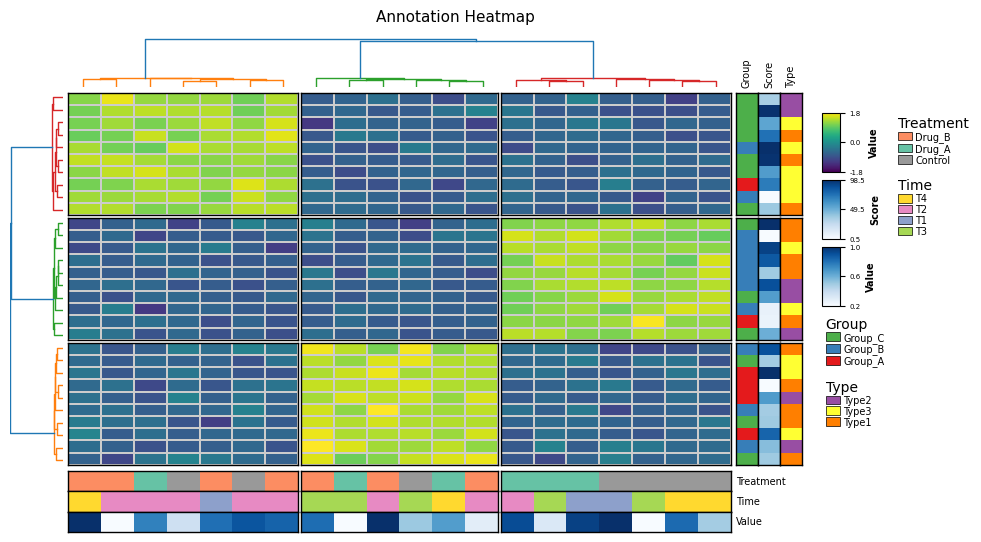

In [10]:
# ============================================================
# 4. Plot the Heatmap
# ============================================================
fig = eheatmap(
    df,
    scale="row",                    # Row Z-score normalization
    cutree_rows=3,                  # Split rows into 3 clusters
    cutree_cols=3,                  # Split columns into 3 groups
    annotation_row=row_anno,        # Row annotations
    annotation_col=col_anno,        # Column annotations
    annotation_colors=annotation_colors,  # Custom color mapping
    color="viridis",                # CNS-recommended colormap
    center=0,                       # Color center point
    border_color="grey80",          # Cell border color
    fontsize=9,
    dendrogram_linewidth=1,
    treeheight_col=40,
    treeheight_row=20,
    dendrogram_colors="colorful",
    split_border_color="black",     # Split line color
    split_border_width=1.0,
    legend=True,
    annotation_legend=True,
    main="Annotation Heatmap"
)
